# Precipitation

Lee el raw local de NOAA desde `ml4c-pro/data/raw/weather/noaa_precip_raw.csv`, cruza las estaciones con `data/temporal/noaa/4308211.csv`, genera Thiessen recortado a NYC y segmenta eventos de lluvia por estación.

Regla de eventos:
- separación mínima: `6 h` sin lluvia;
- umbral mínimo del evento: `1.1 mm`;
- limpieza previa: valores negativos fuera.

Como el raw disponible es diario, la misma lógica queda lista para subdiario sin cambiar el notebook.


In [1]:
import os
from datetime import date, timedelta
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from shapely import make_valid, voronoi_polygons
from shapely.ops import unary_union

MPLCONFIGDIR = Path('/tmp/matplotlib')
MPLCONFIGDIR.mkdir(parents=True, exist_ok=True)
os.environ.setdefault('MPLCONFIGDIR', str(MPLCONFIGDIR))

plt.style.use('seaborn-v0_8-whitegrid')

def find_project_root() -> Path:
    """Locate the repository root from any notebook working directory."""
    current = Path.cwd().resolve()
    for candidate in (current, *current.parents):
        if (candidate / 'pyproject.toml').exists() and (candidate / 'data').exists():
            return candidate
    return current


ROOT = find_project_root()
ML4C_ROOT = Path('/home/map10194/Documents/ml4c/ml4c-pro')

INVENTORY_PATH = ROOT / 'data' / 'temporal' / 'noaa' / '4308211.csv'
RAW_PRECIP_CANDIDATES = [
    ML4C_ROOT / 'data/raw/weather/noaa_precip_raw.csv',
    ROOT / 'data/temporal/noaa/noaa_precip_raw.csv',
]
SPATIAL_OUTPUT_DIR = ROOT / 'data' / 'spatial' / 'vector' / 'noaa'
TEMPORAL_OUTPUT_DIR = ROOT / 'data' / 'temporal' / 'noaa'
EVENT_DIR = TEMPORAL_OUTPUT_DIR / 'precip_events'
EVENT_SUMMARY_PATH = TEMPORAL_OUTPUT_DIR / 'precipitation_event_summary.csv'
for folder in (SPATIAL_OUTPUT_DIR, TEMPORAL_OUTPUT_DIR, EVENT_DIR):
    folder.mkdir(parents=True, exist_ok=True)

EVENT_GAP = pd.Timedelta(hours=6)
MIN_EVENT_MM = 1.1
TARGET_CRS = 4326


In [2]:
def load_nyc_boundary():
    """Load the NYC borough polygons and a valid union geometry."""
    nyc = gpd.read_file(ROOT / 'data' / 'spatial' / 'vector' / 'nyc_borough_boundary' / 'nybb.geojson')
    nyc = nyc.copy()
    nyc['geometry'] = nyc.geometry.apply(make_valid)
    city = unary_union(nyc.geometry)
    return nyc, city


def build_thiessen(points_gdf, clip_geom):
    """Build Thiessen polygons, clipped to the NYC union geometry."""
    if len(points_gdf) < 2:
        raise ValueError('Se necesitan al menos dos estaciones para construir Thiessen.')
    diagram = voronoi_polygons(
        unary_union(points_gdf.geometry),
        extend_to=clip_geom,
        ordered=True,
    )
    rows = []
    base_rows = points_gdf.drop(columns='geometry').to_dict('records')
    for record, cell in zip(base_rows, diagram.geoms):
        clipped = cell.intersection(clip_geom)
        if clipped.is_empty:
            continue
        record = dict(record)
        record['geometry'] = clipped
        rows.append(record)
    return gpd.GeoDataFrame(rows, crs=points_gdf.crs)


def load_station_inventory():
    """Load the station inventory with coordinates and NOAA ids."""
    inventory = pd.read_csv(
        INVENTORY_PATH,
        usecols=['STATION', 'NAME', 'LATITUDE', 'LONGITUDE'],
        dtype={'STATION': 'string', 'NAME': 'string'},
    ).drop_duplicates('STATION')
    inventory = inventory.rename(
        columns={
            'STATION': 'station_code',
            'NAME': 'station_name',
            'LATITUDE': 'lat',
            'LONGITUDE': 'lon',
        }
    )
    inventory['station_id'] = 'GHCND:' + inventory['station_code'].astype(str)
    inventory['role'] = 'inventory'
    return inventory.sort_values('station_id').reset_index(drop=True)


def raw_precip_path():
    """Return the first available raw precipitation file."""
    for path in RAW_PRECIP_CANDIDATES:
        if path.exists():
            return path
    raise FileNotFoundError(
        'No se encontro el raw de precipitacion. ' + ', '.join(str(path) for path in RAW_PRECIP_CANDIDATES)
    )


def load_raw_precip():
    """Load and clean the raw NOAA precipitation series."""
    path = raw_precip_path()
    raw = pd.read_csv(path, low_memory=False)
    expected = {'date', 'station', 'value'}
    missing = expected - set(raw.columns)
    if missing:
        raise ValueError(f'El raw de precipitacion no tiene las columnas esperadas: {sorted(missing)}')
    raw = raw.rename(columns={'date': 'timestamp', 'station': 'station_id', 'value': 'precip_mm'})
    raw['timestamp'] = pd.to_datetime(raw['timestamp'], errors='coerce')
    raw['station_id'] = raw['station_id'].astype('string')
    raw['precip_mm'] = pd.to_numeric(raw['precip_mm'], errors='coerce')
    raw = raw.dropna(subset=['timestamp', 'station_id', 'precip_mm'])
    raw = raw.loc[raw['precip_mm'] >= 0].copy()
    raw['source_file'] = path.name
    raw['source_path'] = str(path)
    return raw.sort_values(['station_id', 'timestamp']).reset_index(drop=True)


def set_map_extent(ax, geom, pad=0.03):
    """Set a small padded view around a geometry."""
    minx, miny, maxx, maxy = geom.bounds
    dx = (maxx - minx) * pad
    dy = (maxy - miny) * pad
    ax.set_xlim(minx - dx, maxx + dx)
    ax.set_ylim(miny - dy, maxy + dy)


def split_rain_events(station_frame, station_id, station_name, gap=EVENT_GAP, min_total=MIN_EVENT_MM):
    """Split one station series into independent rain events and write a CSV per event."""
    frame = station_frame.copy().sort_values('timestamp').reset_index(drop=True)
    frame = frame.dropna(subset=['timestamp', 'precip_mm'])
    frame = frame.loc[frame['precip_mm'] >= 0].copy()

    wet = frame.loc[frame['precip_mm'] > 0, ['timestamp', 'precip_mm']].copy()
    if wet.empty:
        empty = pd.DataFrame(
            columns=[
                'station_id', 'station_name', 'event_id', 'event_uid', 'start', 'end',
                'duration_hours', 'precip_mm', 'n_records', 'wet_records', 'csv_path',
            ]
        )
        return empty

    wet['time_diff'] = wet['timestamp'].diff()
    wet['is_new_event'] = wet['time_diff'].isna() | (wet['time_diff'] > gap)
    wet['event_id'] = wet['is_new_event'].cumsum().astype(int)

    summaries = []
    station_slug = str(station_id).replace(':', '_')
    station_dir = EVENT_DIR / station_slug
    station_dir.mkdir(parents=True, exist_ok=True)

    for event_id, wet_group in wet.groupby('event_id'):
        start = wet_group['timestamp'].min()
        end = wet_group['timestamp'].max()
        event_frame = frame.loc[(frame['timestamp'] >= start) & (frame['timestamp'] <= end)].copy()
        total_mm = float(event_frame['precip_mm'].sum())
        if total_mm < min_total:
            continue

        event_uid = f'{station_slug}_{int(event_id):04d}'
        event_path = station_dir / f'event_{int(event_id):04d}.csv'
        event_frame = event_frame.assign(
            event_id=int(event_id),
            event_uid=event_uid,
            station_id=station_id,
            station_name=station_name,
        )
        event_frame.to_csv(event_path, index=False)

        summaries.append(
            {
                'station_id': station_id,
                'station_name': station_name,
                'event_id': int(event_id),
                'event_uid': event_uid,
                'start': start,
                'end': end,
                'duration_hours': float((end - start).total_seconds() / 3600.0),
                'precip_mm': total_mm,
                'n_records': int(len(event_frame)),
                'wet_records': int(len(wet_group)),
                'csv_path': str(event_path),
            }
        )

    return pd.DataFrame(summaries)


In [3]:
nyc_boroughs, nyc_union = load_nyc_boundary()
inventory = load_station_inventory()
raw_precip = load_raw_precip()

active_station_ids = set(raw_precip['station_id'].dropna().astype(str).unique().tolist())
active_inventory = inventory[inventory['station_id'].isin(active_station_ids)].copy().sort_values('station_id').reset_index(drop=True)
active_inventory['station_id'] = active_inventory['station_id'].astype('string')

if active_inventory.empty:
    raise ValueError('No hay estaciones en el raw de precipitacion que coincidan con el inventario.')

seed_points = gpd.GeoDataFrame(
    active_inventory,
    geometry=gpd.points_from_xy(active_inventory['lon'], active_inventory['lat']),
    crs='EPSG:4326',
)
seed_thiessen = build_thiessen(seed_points, nyc_union)
city_station_ids = set(seed_thiessen['station_id'].astype(str))
city_stations = active_inventory[active_inventory['station_id'].isin(city_station_ids)].copy().sort_values('station_id').reset_index(drop=True)
city_points = gpd.GeoDataFrame(
    city_stations,
    geometry=gpd.points_from_xy(city_stations['lon'], city_stations['lat']),
    crs='EPSG:4326',
)

raw_precip = raw_precip.merge(
    active_inventory[['station_id', 'station_name', 'lat', 'lon']],
    on='station_id',
    how='left',
)
raw_precip['source_kind'] = 'daily_raw'
raw_precip


,timestamp,datatype,station_id,attributes,precip_mm,source_file,source_path,station_name,lat,lon,source_kind
0,2010-01-01,PRCP,GHCND:USW00014732,",,0,2400",0.3,noaa_precip_raw.csv,/home/map10194/Documents/ml4c/ml4c-pro/data/ra...,"LAGUARDIA AIRPORT, NY US",40.77945,-73.88027,daily_raw
1,2010-01-02,PRCP,GHCND:USW00014732,"T,,0,2400",0.0,noaa_precip_raw.csv,/home/map10194/Documents/ml4c/ml4c-pro/data/ra...,"LAGUARDIA AIRPORT, NY US",40.77945,-73.88027,daily_raw
2,2010-01-03,PRCP,GHCND:USW00014732,"T,,0,2400",0.0,noaa_precip_raw.csv,/home/map10194/Documents/ml4c/ml4c-pro/data/ra...,"LAGUARDIA AIRPORT, NY US",40.77945,-73.88027,daily_raw
3,2010-01-04,PRCP,GHCND:USW00014732,",,0,2400",0.0,noaa_precip_raw.csv,/home/map10194/Documents/ml4c/ml4c-pro/data/ra...,"LAGUARDIA AIRPORT, NY US",40.77945,-73.88027,daily_raw
4,2010-01-05,PRCP,GHCND:USW00014732,",,0,2400",0.0,noaa_precip_raw.csv,/home/map10194/Documents/ml4c/ml4c-pro/data/ra...,"LAGUARDIA AIRPORT, NY US",40.77945,-73.88027,daily_raw
...,...,...,...,...,...,...,...,...,...,...,...
11893,2026-04-11,PRCP,GHCND:USW00094728,",,1,2400",0.0,noaa_precip_raw.csv,/home/map10194/Documents/ml4c/ml4c-pro/data/ra...,"NY CITY CENTRAL PARK, NY US",40.77898,-73.96925,daily_raw
11894,2026-04-12,PRCP,GHCND:USW00094728,",,1,2400",0.0,noaa_precip_raw.csv,/home/map10194/Documents/ml4c/ml4c-pro/data/ra...,"NY CITY CENTRAL PARK, NY US",40.77898,-73.96925,daily_raw
11895,2026-04-13,PRCP,GHCND:USW00094728,"T,,1,2400",0.0,noaa_precip_raw.csv,/home/map10194/Documents/ml4c/ml4c-pro/data/ra...,"NY CITY CENTRAL PARK, NY US",40.77898,-73.96925,daily_raw
11896,2026-04-14,PRCP,GHCND:USW00094728,"T,,1,2400",0.0,noaa_precip_raw.csv,/home/map10194/Documents/ml4c/ml4c-pro/data/ra...,"NY CITY CENTRAL PARK, NY US",40.77898,-73.96925,daily_raw


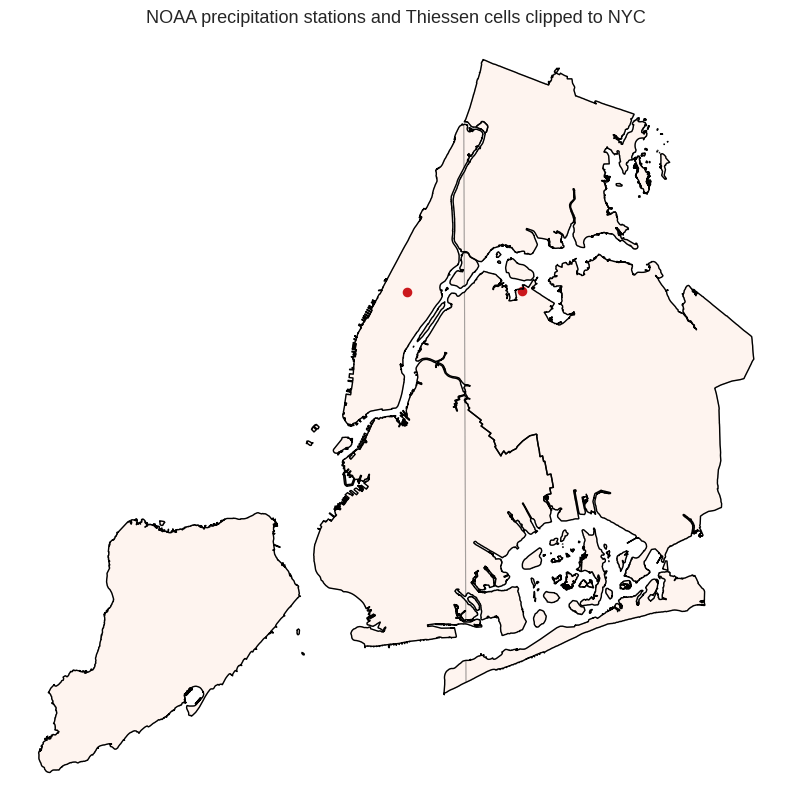

,station_id,station_name,geometry
0,GHCND:USW00014732,"LAGUARDIA AIRPORT, NY US","MULTIPOLYGON (((-73.92514 40.85185, -73.92515 ..."
1,GHCND:USW00094728,"NY CITY CENTRAL PARK, NY US","MULTIPOLYGON (((-73.92361 40.56207, -73.9233 4..."


In [4]:
# Mapa: red seed, red activa para NYC y Thiessen recortado.
fig, ax = plt.subplots(figsize=(10, 10))
nyc_boroughs.boundary.plot(ax=ax, color='black', linewidth=1)
seed_points.plot(ax=ax, color='0.78', markersize=12, alpha=0.45)
seed_thiessen.plot(ax=ax, color='#fee0d2', alpha=0.35, edgecolor='0.35', linewidth=0.8)
city_points.plot(ax=ax, color='#cb181d', markersize=35)
set_map_extent(ax, nyc_union, pad=0.04)
ax.set_title('NOAA precipitation stations and Thiessen cells clipped to NYC', fontsize=13)
ax.set_axis_off()
plt.show()

seed_thiessen[['station_id', 'station_name', 'geometry']]


In [5]:
# Guardar capas espaciales.
seed_points_out = SPATIAL_OUTPUT_DIR / 'precipitation_seed_stations.geojson'
city_points_out = SPATIAL_OUTPUT_DIR / 'precipitation_city_stations.geojson'
thiessen_out = SPATIAL_OUTPUT_DIR / 'precipitation_thiessen.geojson'
seed_points.to_file(seed_points_out, driver='GeoJSON')
city_points.to_file(city_points_out, driver='GeoJSON')
seed_thiessen.to_file(thiessen_out, driver='GeoJSON')
print(seed_points_out)
print(city_points_out)
print(thiessen_out)


/home/map10194/Documents/urban-flood-stress/data/spatial/vector/noaa/precipitation_seed_stations.geojson
/home/map10194/Documents/urban-flood-stress/data/spatial/vector/noaa/precipitation_city_stations.geojson
/home/map10194/Documents/urban-flood-stress/data/spatial/vector/noaa/precipitation_thiessen.geojson


In [6]:
# Segmentación de eventos por estación y exportación de CSV por evento.
event_tables = []
for row in city_stations.to_dict('records'):
    station_id = row['station_id']
    station_name = row['station_name']
    series = raw_precip.loc[raw_precip['station_id'] == station_id].copy()
    if series.empty:
        continue
    event_table = split_rain_events(series, station_id, station_name)
    if not event_table.empty:
        event_tables.append(event_table)

event_summary = pd.concat(event_tables, ignore_index=True) if event_tables else pd.DataFrame(
    columns=[
        'station_id', 'station_name', 'event_id', 'event_uid', 'start', 'end',
        'duration_hours', 'precip_mm', 'n_records', 'wet_records', 'csv_path',
    ]
)
event_summary = event_summary.sort_values(['station_id', 'start', 'event_id'], kind='stable').reset_index(drop=True)
event_summary.to_csv(EVENT_SUMMARY_PATH, index=False)
event_summary


,station_id,station_name,event_id,event_uid,start,end,duration_hours,precip_mm,n_records,wet_records,csv_path
0,GHCND:USW00014732,"LAGUARDIA AIRPORT, NY US",3,GHCND_USW00014732_0003,2010-01-17,2010-01-17,0.0,9.9,1,1,/home/map10194/Documents/urban-flood-stress/da...
1,GHCND:USW00014732,"LAGUARDIA AIRPORT, NY US",6,GHCND_USW00014732_0006,2010-01-25,2010-01-25,0.0,31.0,1,1,/home/map10194/Documents/urban-flood-stress/da...
2,GHCND:USW00014732,"LAGUARDIA AIRPORT, NY US",7,GHCND_USW00014732_0007,2010-01-28,2010-01-28,0.0,2.0,1,1,/home/map10194/Documents/urban-flood-stress/da...
3,GHCND:USW00014732,"LAGUARDIA AIRPORT, NY US",9,GHCND_USW00014732_0009,2010-02-03,2010-02-03,0.0,2.0,1,1,/home/map10194/Documents/urban-flood-stress/da...
4,GHCND:USW00014732,"LAGUARDIA AIRPORT, NY US",10,GHCND_USW00014732_0010,2010-02-10,2010-02-10,0.0,26.4,1,1,/home/map10194/Documents/urban-flood-stress/da...
...,...,...,...,...,...,...,...,...,...,...,...
3067,GHCND:USW00094728,"NY CITY CENTRAL PARK, NY US",2049,GHCND_USW00094728_2049,2026-03-22,2026-03-22,0.0,3.8,1,1,/home/map10194/Documents/urban-flood-stress/da...
3068,GHCND:USW00094728,"NY CITY CENTRAL PARK, NY US",2050,GHCND_USW00094728_2050,2026-03-23,2026-03-23,0.0,10.2,1,1,/home/map10194/Documents/urban-flood-stress/da...
3069,GHCND:USW00094728,"NY CITY CENTRAL PARK, NY US",2053,GHCND_USW00094728_2053,2026-04-01,2026-04-01,0.0,2.3,1,1,/home/map10194/Documents/urban-flood-stress/da...
3070,GHCND:USW00094728,"NY CITY CENTRAL PARK, NY US",2054,GHCND_USW00094728_2054,2026-04-02,2026-04-02,0.0,1.8,1,1,/home/map10194/Documents/urban-flood-stress/da...


In [7]:
# Resumen rápido.
print(f'Eventos detectados: {len(event_summary):,}')
display(
    event_summary.groupby('station_id', dropna=False)
    .agg(
        events=('event_id', 'size'),
        total_mm=('precip_mm', 'sum'),
        max_mm=('precip_mm', 'max'),
    )
    .sort_values('events', ascending=False)
)


Eventos detectados: 3,072


,events,total_mm,max_mm
station_id,,,
GHCND:USW00094728,1569,20395.2,181.1
GHCND:USW00014732,1503,18681.5,172.7
